In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

import boto3
import os

session = boto3.Session(
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_DEFAULT_REGION")
)

In [2]:
import mlflow

mlflow.set_tracking_uri("http://ec2-98-89-26-222.compute-1.amazonaws.com:5000")

In [6]:
mlflow.set_experiment('Exp 4 - handling imbalanced data')

<Experiment: artifact_location='s3://mlflow-bucket-carlos/4', creation_time=1772596088824, experiment_id='4', last_update_time=1772596088824, lifecycle_stage='active', name='Exp 4 - handling imbalanced data', tags={}>

In [8]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [9]:
df = pd.read_csv('reddit_preprocessing.csv')
df.dropna(inplace = True)
print(df.shape)

df.head()

(36662, 2)


,clean_comment,category
0,family mormon never tried explain still stare ...,1
1,buddhism much lot compatible christianity espe...,1
2,seriously say thing first get complex explain ...,-1
3,learned want teach different focus goal not wr...,0
4,benefit may want read living buddha living chr...,1


----- class_weights
🏃 View run Imbalance_class_weights,RandomForest_TFIDF_Trigrams at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/4/runs/0d9320cb6b824f61b2d2b213845515c1
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/4
Accuracy: 0.6819855447974909
----- oversampling
🏃 View run Imbalance_oversampling,RandomForest_TFIDF_Trigrams at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/4/runs/181837177c12460993c07b4d056bdbe6
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/4
Accuracy: 0.6814400654575208
----- undersampling
🏃 View run Imbalance_undersampling,RandomForest_TFIDF_Trigrams at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/4/runs/01d1fa44143c4bb2845cc1d2f1b4887f
🧪 View experiment at: http://ec2-98-89-26-222.compute-1.amazonaws.com:5000/#/experiments/4
Accuracy: 0.6804854766125733
----- adasyn
🏃 View run Imbalance_adasyn,RandomForest_TFIDF_

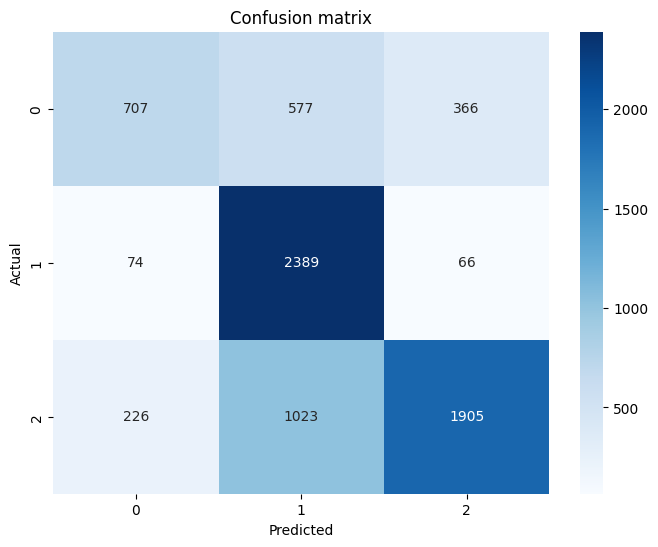

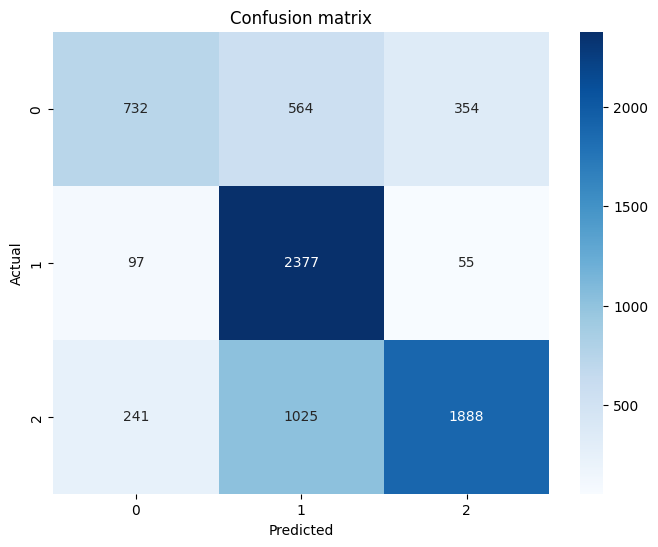

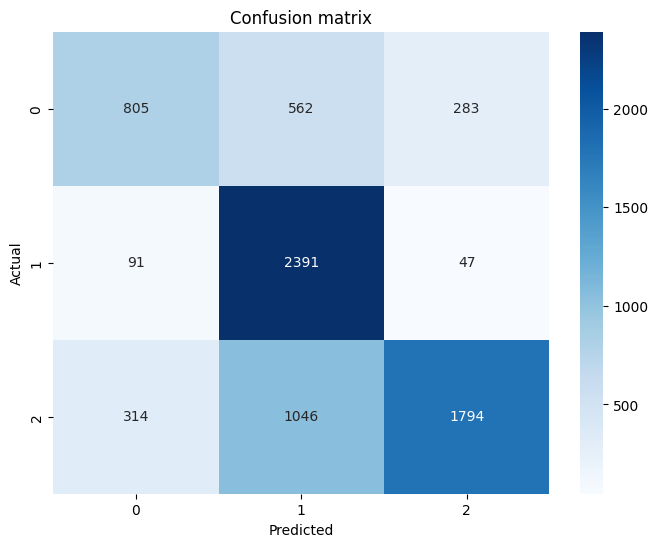

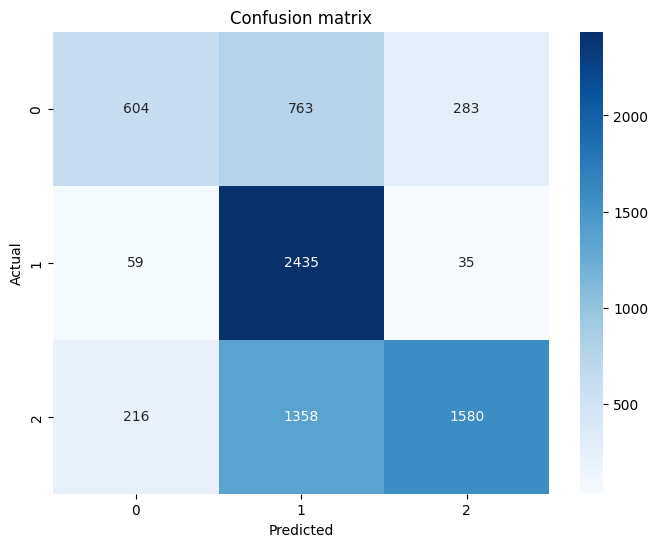

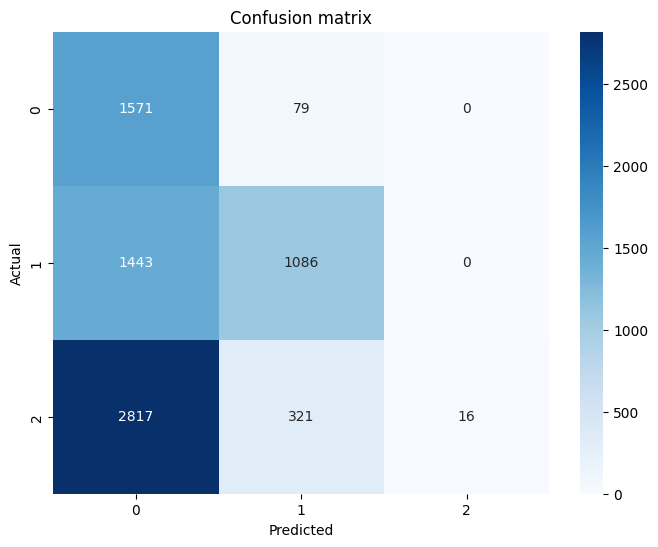

In [13]:
def run_imbalanced_experiment(imbalance_method):
    ngram_range = (1,3)
    max_features = 10000
    
    vectorizer = TfidfVectorizer(ngram_range = ngram_range, max_features = max_features)
    
    X_train, X_test, y_train, y_test = train_test_split(df.clean_comment, df.category, test_size = 0.2, random_state = 42, stratify = df.category)
    
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    if imbalance_method == 'class_weights':
        class_weight = 'balanced'
    else:
        class_weight = None
        
        if imbalance_method == 'oversampling':
            smote = SMOTE(random_state = 42)
            X_train_vec, y_train = smote.fit_resample(X_train_vec, y_train)
        elif imbalance_method == 'adasyn':
            adasyn = ADASYN(random_state = 42)
            X_train_vec, y_train = adasyn.fit_resample(X_train_vec, y_train)
        elif imbalance_method == 'undersampling':
            rus = RandomUnderSampler(random_state = 42)
            X_train_vec, y_train = rus.fit_resample(X_train_vec, y_train)
        elif imbalance_method == 'smote_enn':
            smote_enn = SMOTEENN(random_state = 42)
            X_train_vec, y_train = smote_enn.fit_resample(X_train_vec, y_train)
            
    with mlflow.start_run() as run:
        mlflow.set_tag('mlflow.runName', f'Imbalance_{imbalance_method},RandomForest_TFIDF_Trigrams')
        mlflow.set_tag('experiment_type','imbalance_handling')
        mlflow.set_tag('model_type','RandomForestClassifier')
        
        mlflow.set_tag('description',f'RandomForest with TF-IDF Trigrams, imbalance handling method = {imbalance_method} ,max_features = {max_features}')
        
        mlflow.log_param('vectorizer_type','TF-IDF')
        mlflow.log_param('ngram_range', ngram_range)
        mlflow.log_param('vectorizer_max_features',max_features)
        
        n_estimators = 200
        max_depth = 15
        
        mlflow.log_param('max_estimators', n_estimators)
        mlflow.log_param('max_depth', max_depth)
        mlflow.log_param('imbalance_method', imbalance_method)
        
        model = RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, random_state = 42, class_weight = class_weight)
        model.fit(X_train_vec, y_train)
        
        y_pred = model.predict(X_test_vec)
        
        accuracy = accuracy_score(y_test, y_pred)
        mlflow.log_metric('accuracy', accuracy)
        
        classification_rep = classification_report(y_test, y_pred, output_dict = True)
    
        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):
                for metric, value in metrics.items():
                    mlflow.log_metric(f'{label}_{metric}', value)
                    
        conf_matrix = confusion_matrix(y_test, y_pred)
        plt.figure(figsize = (8,6))
        sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion matrix')
        
        plt.savefig('confusion_matrix.png')
        mlflow.log_artifact("confusion_matrix.png")
        
        df.to_csv('dataset.csv', index = False)
        mlflow.log_artifact('dataset.csv')
        
        mlflow.sklearn.log_model(
            model,
            f"random_forest_model_tfidf_trigrams_imbalance_{imbalance_method}",
            input_example=X_train_vec[:5]
        )
        
    print(f'Accuracy: {accuracy}')
    
imbalance_methods = ['class_weights','oversampling','undersampling','adasyn','smote_enn']

for method in imbalance_methods:
    print('-'*5,method)
    run_imbalanced_experiment(method)
    